# DA stim photometry — PSTH by stim condition

Loading and clock alignment live in `photometry_data.py`.

Behavior and photometry are joined through `PhotoData.IOsync`, a 1 kHz digital
line Bpod holds HIGH for each trial's ITI: one rising edge per trial start, one
falling edge at cue onset.

**Every dopamine panel below is aligned on those edges directly** — trial start
is the rising edge, cue is the falling edge, reward is the falling edge plus the
protocol's 1.5 s trace period. That needs no behavior file and no clock fit, so
a photometry recording whose Bpod partner is missing still gets its PSTHs; what
it loses is the two things only Bpod knows, **licking** and **stim level**.

The clock fit is still what makes licking possible. `align()` fits a global line
through all the edges to recover the clock *rate*, then **anchors each trial to
its own rising edge** — a trial-relative time `rel` lands at
`anchors[i] + rel * slope`. So no error accumulates across the session, and a bad
edge stays confined to its own trial. Pass `anchor="fit"` to `event_times` /
`epoch` / `lick_times` to use the global line instead. Section 2 shows the two
routes agreeing: cue onset via the fit lands within 1 ms of the edge it marks.


In [21]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, r"c:\Misc_Coding\Uchida_lab\Behavior_plotting")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import photometry_data as pdm

# ---- where the data lives -------------------------------------------------
BEHAVIOR_ROOT = r"D:\WXC-related\Harvard\Uchida lab\Behavior_data"
PHOTOMETRY_ROOT = r"D:\WXC-related\Harvard\Uchida lab\Photometry_data"

# ---- which sessions to work on --------------------------------------------
# None means "everything". Each photometry file is ~45 MB, so as these folders
# fill up, narrow this rather than loading the lot.
ANIMALS = ["SW007", "SW008", "SW010"]
DATES = ["20260906"]

# ---- sync pulses that are not trials --------------------------------------
# Bpod toggled the line before the first real trial on these two, leaving a
# 0.3 s / 0.8 s HIGH where an ITI is ~9 s. Dropping it here fixes both consumers
# at once: align() stops reporting 101 pulses for 100 trials, and the TTL event
# times -- which pair the edges positionally -- stop being off by one trial.
# The load lines below flag any session that needs an entry here.
SKIP_PULSES = {"SW008_20260906": 1, "SW010_20260906": 1}

# list_pairs() only reads file names and sizes -- nothing is loaded yet, so this
# stays fast however big the folders get. Check it before committing to a load.
pdm.list_pairs(BEHAVIOR_ROOT, PHOTOMETRY_ROOT, animals=ANIMALS, dates=DATES)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,animal,date,protocol,matched,photometry MB,behavior file,photometry file
0,SW007,20260906,WaterDeliveryPhotometry_DA_stim,True,43.7,SW007_WaterDeliveryPhotometry_DA_stim_20260906...,SW007_20260906_photometry_0002_Photodata.mat
1,SW008,20260906,WaterDeliveryPhotometry_DA_stim,True,43.7,SW008_WaterDeliveryPhotometry_DA_stim_20260906...,SW008_20260906_photometry_0002_Photodata.mat
2,SW010,20260906,WaterDeliveryPhotometry_DA_stim,True,43.6,SW010_WaterDeliveryPhotometry_DA_stim_20260906...,SW010_20260906_photometry_0002_Photodata.mat


In [22]:
sessions = pdm.load_all(BEHAVIOR_ROOT, PHOTOMETRY_ROOT,
                        animals=ANIMALS, dates=DATES, skip_pulses=SKIP_PULSES)

SW007 20260906   100 trials   1686.8s  100 anchored  fit resid  0.55 ms
SW008 20260906   100 trials   1686.8s  100 anchored  fit resid  0.49 ms  (first 1 pulse(s) dropped)
SW010 20260906   100 trials   1686.8s  100 anchored  fit resid  0.51 ms  (first 1 pulse(s) dropped)


In [ ]:
# check alignment of photometry sync pulses with trial events
rows = []
for name, s in sessions.items():
    a = s.alignment
    falls = s.photo.sync_falls
    rows.append({
        "session": name,
        "trials": len(s.trials),
        "sync pulses": a.n_pulses,
        "anchored": a.n_anchored,
        "slope": round(a.slope, 9),
        "offset (s)": round(a.intercept, 4),
        "fit resid (ms)": round(a.max_residual * 1e3, 3),
        # trial_start must sit exactly on its own edge under per-trial anchoring
        "start-on-edge (ms)": round(
            np.abs(s.event_times("trial_start", anchor="trial") - a.anchors).max() * 1e3, 4),
        "cue err, anchored (ms)": round(
            np.abs(s.event_times("Cue1_on", anchor="trial") - falls).max() * 1e3, 3),
        "cue err, fit (ms)": round(
            np.abs(s.event_times("Cue1_on", anchor="fit") - falls).max() * 1e3, 3),
    })
pd.DataFrame(rows)

,session,trials,sync pulses,anchored,slope,offset (s),fit resid (ms),start-on-edge (ms),"cue err, anchored (ms)","cue err, fit (ms)"
0,SW007_20260905,100,100,100,1.000010,46.7873,0.536,0.0,0.882,0.599
1,SW008_20260905,100,100,100,1.000013,68.1403,0.502,0.0,0.965,0.514
2,SW010_20260905,100,100,100,1.000010,96.5615,0.511,0.0,0.924,0.525


## 3. PSTH by stim condition, with licking

Aligned on the **TTL rising edge** — ITI onset, which is when the stim fires.
Splitting those trials by stim level is the one part that needs Bpod, so a
recording with no behavior file still gets its two dopamine rows, drawn as a
single unlabelled curve over all trials, and says so where the lick row would be.

Stim level is an **ordered** variable, so the three conditions take one sequential
blue ramp (light → dark) rather than three unrelated hues — the colour ordering
then carries the dose ordering. No-stim trials are drawn in recessive grey as a
reference. Bands are ± SEM across trials.

Three rows, one per measure, sharing the x-axis — never one plot with two y-axes,
which would let their relative amplitudes be set by an arbitrary choice of scaling:

1. **$\Delta$F**, baseline-subtracted. Comparable *within* an animal.
2. **z**, the same dopamine signal with each trial divided by the SD of its own
   baseline. This is the row to read *across* animals; the closing section is why.
3. **lick rate**, to see whether the stim moves behaviour at all.

y-axes are shared within a row, so sessions stay comparable; colour still encodes
stim level, so each column reads top-to-bottom as one condition.

Two things the lick rate needs that the $\Delta$F does not:

- **Pool the licks before windowing.** Bpod stores lick times trial-relative, so a
  lick shortly before a trial start is filed under the *previous* trial. Binning
  each trial's own array would put a flat, artifactual 0 Hz everywhere left of
  t = 0. `lick_train()` pools the session onto the photometry clock first.
- **Count in a sliding window.** Licks are sparse here (< 2 Hz) and the stim
  conditions have n = 10, so narrow fixed bins are hash — every bin holds 0, 1, or
  2 licks. The rate counts licks in a **10-bin window of 100 ms bins (1 s)**,
  stepped one bin at a time, so successive points overlap by 9/10 of a window and
  the trace is continuous rather than chunky. Counted per trial, so the ± SEM band
  describes the curve actually drawn.

One thing to keep in mind about the +5 s tail: the shortest ITI is 4.01 s on
20260905 but only 2.50 s on 20260904, so cue onset enters the window on the
shorter-ITI trials. Past that point the average is a mix of still-in-ITI and
already-cued trials, not a clean post-stim baseline — and how far out that stays
true is a property of the day, not of this figure.


In [23]:
# Ordinal ramp, blue steps 250/450/650, validated light+dark:
# monotone L, adjacent dL 0.19, light end 2.06:1 vs surface, hue spread 3 deg.
STIM_COLOR = {0: "#898781", 1: "#86b6ef", 2: "#2a78d6", 3: "#104281"}
INK, INK_2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
SURFACE = "#fcfcfb"

WINDOW, BASELINE = (-1.0, 5.0), (-1.0, -0.1)
LICK_BIN, LICK_WIN_BINS = 0.1, 10  # 100 ms bins, sliding window of 10 = 1 s

# Cue -> reward, seconds. Measured rather than assumed: across the 300 paired
# trials of 20260905, Cue1_on sits on the falling edge to within 0.9 ms and
# Reward_on - fall is 1.5001 s (range 1.4994-1.5010). Section 5 re-checks it per
# recording by reporting where the DA transient actually lands.
TTL_TRACE = 1.5


def ttl_events(photo, event, trace=TTL_TRACE, anchors=None):
    """Photometry-clock event times, read off the sync line rather than Bpod.

    IOsync is HIGH for each trial's ITI, so the line carries the trial structure
    by itself: "trial_start" is the rising edge (ITI onset, and stim onset on a
    stim day), "cue" the falling edge, "reward" the falling edge + ``trace``.

    This is the alignment every dopamine panel below uses, whether or not there
    is a behavior file. On a paired session it agrees with Bpod to under a
    millisecond (section 2's table) while needing no clock fit at all -- the fit
    is still what brings Bpod's *lick* times onto this clock.

    anchors  None -> one entry per complete trial in the recording.
             A session's per-trial rising edges (``sess.alignment.anchors``) ->
             one entry per *Bpod trial*, NaN where that trial has no edge of its
             own, which is what keeps rows lined up with the trial table.
    """
    rises, falls = photo.sync_rises, photo.sync_falls
    if anchors is None:
        n = min(rises.size, falls.size)   # a recording cut mid-trial leaves a
        start, cue = rises[:n], falls[:n]  # trailing rise with no fall
    else:
        start = np.asarray(anchors, dtype=float)
        # Each trial's cue is the first falling edge after its own rising edge.
        j = np.searchsorted(falls, np.nan_to_num(start, nan=np.inf))
        cue = np.where(j < falls.size, falls[np.clip(j, 0, falls.size - 1)], np.nan)
        cue = np.where(np.isfinite(start), cue, np.nan)
    return {"trial_start": start, "cue": cue, "reward": cue + trace}[event]


def event_times_of(photo, sess, event):
    """ttl_events() for a (photo, sess) pair, anchored per trial where possible."""
    return ttl_events(photo, event,
                      anchors=None if sess is None else sess.alignment.anchors)


def stim_levels(sess, n=None):
    """Per-trial stim level as ints, NaN -> 0; all zeros with no behavior file.

    Stim level is one of the two things only Bpod knows (licking is the other).
    A protocol that never stimulates carries no ``StimTrials`` field, so the
    column arrives all-NaN -- those are level-0 trials, not an error. ``n`` pads
    or truncates to the number of TTL trials actually being plotted.
    """
    v = (np.zeros(0) if sess is None
         else np.nan_to_num(sess.trials["stim"].to_numpy(dtype=float), nan=0.0))
    v = v.astype(int)
    if n is None:
        return v
    return np.concatenate([v, np.zeros(max(0, n - v.size), int)])[:n]


def has_stim(sess):
    """True where the session actually delivered stim on some trials."""
    return sess is not None and bool((stim_levels(sess) > 0).any())


def require_names(names):
    """Refuse to build a figure with no columns, with a message that says why.

    plt.subplots on an empty list raises "Number of columns must be a positive
    integer, not 0" out of gridspec, which says nothing about the real problem:
    an ANIMALS/DATES selection that matched no files.
    """
    if not names:
        raise ValueError(
            "nothing to plot -- no recording matched these ANIMALS / DATES. "
            "Check them against the pdm.list_pairs() table above.")


def session_grid(n_rows, names, col_w=4.1, row_h=2.9):
    """(fig, axes) with one column per recording; axes is always 2-D.

    plt.subplots squeezes the column axis away for a single recording, which
    would leave every figure below indexing axes differently depending on how
    many sessions were selected.
    """
    require_names(names)
    fig, axes = plt.subplots(n_rows, len(names),
                             figsize=(col_w * len(names), row_h * n_rows),
                             sharex=True, sharey="row", dpi=130)
    fig.patch.set_facecolor(SURFACE)
    return fig, np.asarray(axes).reshape(n_rows, len(names))


def _split(t, M, groups):
    """{level: (t, mean, sem, n)} -- the tuple shape every panel below draws."""
    out = {}
    for v in sorted(np.unique(groups)):
        rows = M[groups == v]
        mu, sem = pdm.mean_sem(rows)
        out[int(v)] = (t, mu, sem, rows.shape[0])
    return out


def psth(photo, event, sess=None, which="F", window=WINDOW, baseline=BASELINE,
         norm="sub"):
    """{stim level: (t, mean, sem, n)} for one recording, aligned on the TTL.

    ``event`` is one of ttl_events()'s three, so the alignment needs no behavior
    file. ``sess`` is consulted for one thing only -- which stim level each
    trial belongs to. Pass None and every trial lands in group 0.

    norm  "sub" -> baseline-subtracted, comparable *within* an animal.
          "z"   -> each trial z-scored against the same window, so the unit is
                   SDs of that animal's own noise and panels are comparable
                   *across* animals. The closing table is why that matters.
    """
    t, M = pdm.epoch_signal(photo, event_times_of(photo, sess, event),
                            window, which=which)
    M = (pdm.zscore_baseline if norm == "z" else pdm.baseline_subtract)(M, t, baseline)
    return _split(t, M, stim_levels(sess, M.shape[0]))


def lick_train(sess):
    """Every lick of the session on the photometry clock, sorted.

    Bpod stores lick times trial-relative, so a lick just *before* a trial start
    is recorded in the **previous** trial's array. Pooling the whole session and
    then windowing is what makes the pre-event baseline real; per-trial arrays
    would put an artifactual 0 Hz everywhere left of t=0.
    """
    return np.unique(np.concatenate(sess.lick_times("photometry")))


def lick_rate(sess, times, window=WINDOW, bin_s=LICK_BIN, win_bins=LICK_WIN_BINS):
    """(t, R): per-trial lick rate in licks/s, R shaped (n_events, n_points).

    ``times`` are event times on the photometry clock -- the same TTL times the
    dopamine panels use, so the two rows of a figure are aligned to one event
    and not to two slightly different ones.

    Licks are counted in a ``win_bins``-bin sliding window stepped one bin at a
    time -- at the defaults, a 1 s window every 100 ms, so successive points
    overlap by 9/10 of a window. Split it by condition with lick_psth(), or
    average it whole where every trial is the same condition (section 5).
    """
    span = win_bins * bin_s
    # Overhang half a window each side, then trim: every window kept is filled
    # with real licks rather than running off the end into implicit zeros.
    edges = np.arange(window[0] - span / 2, window[1] + span / 2 + bin_s / 2, bin_s)
    train, ev = lick_train(sess), np.atleast_1d(np.asarray(times, dtype=float))
    C = np.array([np.histogram(train - e, edges)[0] if np.isfinite(e)
                  else np.full(edges.size - 1, np.nan) for e in ev], dtype=float)
    # Moving sum, one bin per step: window i spans edges[i] .. edges[i+win_bins],
    # so its centre is edges[i] + span/2 -- no half-bin offset to correct for.
    cs = np.cumsum(np.pad(C, ((0, 0), (1, 0))), axis=1)
    R = (cs[:, win_bins:] - cs[:, :-win_bins]) / span
    centers = edges[:-win_bins] + span / 2
    keep = (centers >= window[0]) & (centers <= window[1])
    return centers[keep], R[:, keep]


def lick_psth(sess, times, window=WINDOW, bin_s=LICK_BIN, win_bins=LICK_WIN_BINS):
    """{stim level: (t, mean rate, sem, n)} in licks/s -- same shape as psth()."""
    centers, R = lick_rate(sess, times, window, bin_s, win_bins)
    return _split(centers, R, stim_levels(sess, R.shape[0]))


def style_panel(ax, title="", xlabel="", marks=(0,)):
    """The chrome every panel shares: event marks, zero line, spines, ticks.

    ``marks`` are the x positions to dash a vertical line at -- the alignment
    event, plus any fixed landmark around it (cue, on a reward-aligned panel).
    """
    ax.set_facecolor(SURFACE)
    for x in marks:
        if np.isfinite(x):
            ax.axvline(x, color=MUTED, linewidth=1, linestyle=(0, (3, 3)), zorder=1)
    ax.axhline(0, color=GRID, linewidth=1, zorder=0)
    ax.set_title(title, color=INK, fontsize=10, loc="left", pad=8)
    ax.set_xlabel(xlabel, color=INK_2, fontsize=9)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("#c3c2b7")
    ax.tick_params(colors=MUTED, labelsize=8.5)


def draw_psth(ax, curves, title, xlabel, label_peaks=False, stim_known=True):
    """Draw one panel. Takes either psth() or lick_psth() -- same tuple shape."""
    for v, (t, mu, sem, n) in curves.items():
        c = STIM_COLOR[v]
        ax.fill_between(t, mu - sem, mu + sem, color=c, alpha=0.18, linewidth=0,
                        zorder=2 if v else 1)
        # Group 0 is "no stim" only where Bpod said so; on a recording with no
        # behavior file it is simply every trial, unlabelled.
        # n stays out of the TTL-only label: with it, every such panel adds its
        # own near-identical legend entry.
        ax.plot(t, mu, color=c, linewidth=2.0 if v else 1.3, zorder=4 if v else 3,
                label=(f"stim {v}  (n={n})" if v else
                       (f"no stim  (n={n})" if stim_known else "all trials")))

    style_panel(ax, title, xlabel)

    if label_peaks:
        # Direct-label only where the peaks are far enough apart to stay legible.
        peaks = {v: (t[np.nanargmax(mu)], np.nanmax(mu))
                 for v, (t, mu, _, _) in curves.items() if v}
        span = np.ptp(ax.get_ylim())
        for v, (xp, yp) in peaks.items():
            others = [y for u, (_, y) in peaks.items() if u != v]
            if all(abs(yp - y) > 0.06 * span for y in others):
                # Above its own peak: at that x every other curve is further
                # from baseline, so nothing sits in the label's way.
                ax.annotate(f"stim {v}", (xp, yp), xytext=(0, 7), ha="center",
                            textcoords="offset points", color=STIM_COLOR[v],
                            fontsize=8.5, fontweight="bold", zorder=5)


def no_licks_panel(ax, xlabel=""):
    """Say why a lick panel is empty rather than drawing an axis with nothing.

    The x-axis stays on: it is shared down the column, so switching the whole
    axis off would strip that recording's panels of their time scale.
    """
    ax.text(0.5, 0.55, "no behavior file" + chr(10) + "(licking needs Bpod)",
            transform=ax.transAxes, ha="center", va="center", color=MUTED,
            fontsize=9, linespacing=1.5)
    ax.set_yticks([])
    ax.set_xlabel(xlabel, color=INK_2, fontsize=9)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(colors=MUTED, labelsize=8.5)


def figure_legend(fig, axes_row):
    """One legend for the figure, from every distinct label in the top row."""
    seen = {}
    for ax in axes_row:
        for h, lab in zip(*ax.get_legend_handles_labels()):
            seen.setdefault(lab, h)
    if seen:
        fig.legend(list(seen.values()), list(seen), loc="lower center",
                   ncol=max(len(seen), 1), frameon=False,
                   bbox_to_anchor=(0.5, -0.005), fontsize=9, labelcolor=INK_2)


# ---- what gets plotted ----------------------------------------------------
# Every selected recording, paired or not: {name: (photometry, session|None)}.
# A photometry file whose Bpod partner is missing is not a lost session -- the
# sync line still carries the trial structure, so it loses only what Bpod knows.
_, _, _unpaired = pdm.pair_files(BEHAVIOR_ROOT, PHOTOMETRY_ROOT,
                                 animals=ANIMALS, dates=DATES)
recs = {name: (s.photo, s) for name, s in sessions.items()}
for _p in _unpaired:
    # Same pulse fix as the paired loader: a stray edge would otherwise shift
    # every TTL event by one trial here, where there is no behavior file to
    # cross-check against.
    _m = pdm.PHOTO_RE.match(_p.stem)
    _ph = pdm.load_photometry(_p, skip_pulses=(
        pdm.skip_for(SKIP_PULSES, _m["animal"], _m["date"]) if _m else 0))
    recs[f"{_ph.animal}_{_ph.date}" if _ph.animal else _p.stem] = (_ph, None)
recs = dict(sorted(recs.items()))

names = list(recs)
stim_names = [n for n in names if has_stim(recs[n][1])]   # stim level needs Bpod
if not names:
    print("nothing selected -- check ANIMALS / DATES against the pdm.list_pairs() "
          "table above.")
else:
    print(f"{len(names)} recording(s): "
          f"{sum(s is not None for _, s in recs.values())} with behavior, "
          f"{len(stim_names)} with stim trials")


3 recording(s): 3 with behavior, 3 with stim trials


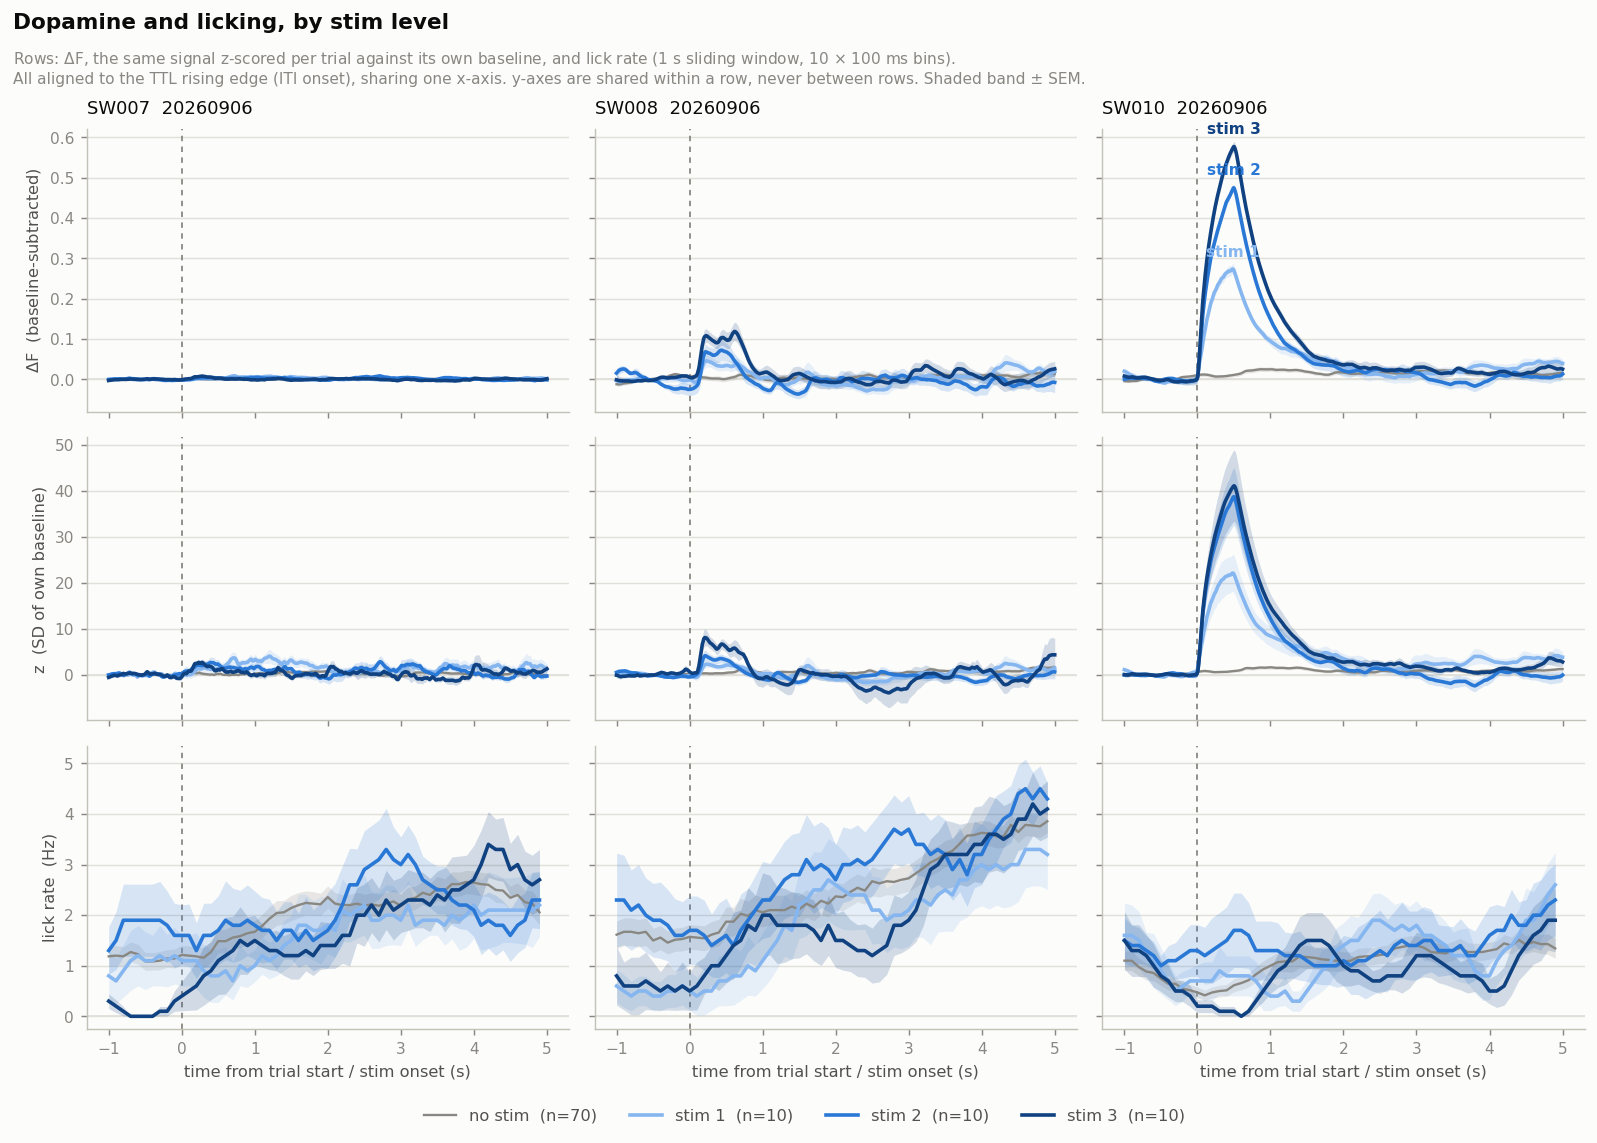

In [24]:
# One row per measure, all sharing the x-axis. Never a twin y-axis: the three
# are in different units, so a single scale would be meaningless. Middle row is
# the same dopamine signal as the top, in each animal's own noise units.
#
# Alignment is the TTL rising edge -- ITI onset, which is where the stim fires.
# Splitting the trials by stim level is the one part that needs Bpod, so a
# recording without a behavior file still gets its dopamine rows, drawn as a
# single unlabelled curve, and says so where the lick row would be.
STIM_ROWS = (("$\\Delta$F  (baseline-subtracted)", "sub"),
             ("z  (SD of own baseline)", "z"),
             ("lick rate  (Hz)", "lick"))
STIM_XLABEL = "time from trial start / stim onset (s)"

fig, axes = session_grid(len(STIM_ROWS), names)
last_stim = stim_names[-1] if stim_names else None

for j, name in enumerate(names):
    photo, sess = recs[name]
    times = event_times_of(photo, sess, "trial_start")
    for r, (_, kind) in enumerate(STIM_ROWS):
        ax = axes[r, j]
        ax.set_facecolor(SURFACE)
        if kind == "lick" and sess is None:
            no_licks_panel(ax, STIM_XLABEL)
            continue
        curves = (lick_psth(sess, times) if kind == "lick"
                  else psth(photo, "trial_start", sess, norm=kind))
        draw_psth(ax, curves,
                  title=(name.replace("_", "  ") + ("   (TTL only)" if sess is None else "")
                         if r == 0 else ""),
                  # the shared x-axis is labelled on the bottom row only
                  xlabel=STIM_XLABEL if r == len(STIM_ROWS) - 1 else "",
                  label_peaks=(r == 0 and name == last_stim),
                  stim_known=sess is not None)

for r, (ylabel, _) in enumerate(STIM_ROWS):
    axes[r, 0].set_ylabel(ylabel, color=INK_2, fontsize=9)
figure_legend(fig, axes[0])

# Reserve the top and bottom strips first, then place the titles into the
# reserved space -- otherwise tight_layout lays out over them.
fig.tight_layout(rect=(0, 0.03, 1, 0.93))
fig.text(0.005, 0.99, "Dopamine and licking, by stim level",
         ha="left", va="top", color=INK, fontsize=12, fontweight="bold")
fig.text(0.005, 0.957, "Rows: $\\Delta$F, the same signal z-scored per trial against "
         "its own baseline, and lick rate (1 s sliding window, 10 × 100 ms bins).\n"
         "All aligned to the TTL rising edge (ITI onset), sharing one x-axis. y-axes are "
         "shared within a row, never between rows. Shaded band ± SEM.",
         ha="left", va="top", color=MUTED, fontsize=8.5)
plt.show()


**Dopamine.** SW008 and SW010 both show a clean monotonic dose-response: stim
1 < 2 < 3 in amplitude, with onset within ~100 ms of trial start, peak near
0.4–0.5 s, and decay back to baseline by ~2 s. SW010 is the strongest and least
variable (peak SEM ≈ 0.01 on n=10).

**The z row agrees with the $\Delta$F row here** — unlike the reward response in
section 5/6, where the two disagree. Stim-3 peaks in SDs of each animal's own
baseline: SW010 **55**, SW008 **9.2**, SW007 **2.0** (no-stim trials sit at 0.1–0.7
for reference). So the between-animal ordering for the stim survives normalisation;
SW010 really does have the biggest stim response by either measure.

**SW007 is flat.** Its stim-3 peak is 0.0036 $\Delta$F, 2.0 SD of its own baseline —
detectable, but ~25× smaller than SW010 in z and far below what the other two show.
On the shared y-axis of the top row it reads as a flat line. Note this is **not** a
dead fiber: section 5 finds a clean reward response on the same trace, and in z units
that response (11.3) is the *largest* of the three mice. The recording works; SW007
just barely responds to the stim, which points at stim delivery rather than at
expression or placement of the fiber.

**Licking does not follow.** SW010's stim 3 drives a 0.58 $\Delta$F transient
peaking at 0.5 s, and nothing happens in its lick trace at that time — the stim
curves sit inside the no-stim band throughout, and the stim levels are not ordered
the way the dopamine is. The animal with the largest DA response is not the one that
licks more.

What licking *does* do is the same in every condition: a slow ramp across the ITI
toward cue onset, worth about +0.35 Hz from baseline (table below: no-stim $\Delta$
= 0.31 / 0.40 / 0.34 across the three sessions). The stim conditions scatter around
that — −0.90 to +0.73 Hz, no dose ordering — which is what an absent effect looks
like at n = 10.

**Read that as "no effect detected", not "no effect".** Baseline lick rates here are
0.1–1.1 Hz on 10 trials per stim level, so only a large change would clear the SEM
bands — and at 10 trials the 1 s window still quantises the rate into steps of
0.1 Hz. Pooling stim levels, or pooling sessions per level, is the cheap way to get
more power out of the data already on disk.

In [6]:
# The read above in numbers: baseline vs post-stim lick rate, per condition.
rows = []
for name in stim_names:
    photo, sess = recs[name]
    times = event_times_of(photo, sess, "trial_start")
    for v, (t, mu, sem, n) in lick_psth(sess, times).items():
        pre, post = mu[t < -0.1], mu[(t >= 0) & (t <= 2)]
        rows.append({"session": name, "stim": v, "n": n,
                     "pre (Hz)": round(float(pre.mean()), 2),
                     "0-2 s (Hz)": round(float(post.mean()), 2),
                     "delta (Hz)": round(float(post.mean() - pre.mean()), 2)})

lick_rates = pd.DataFrame(rows)
if rows:
    display(lick_rates.pivot(index="session", columns="stim", values="delta (Hz)"))
else:
    print("no recording here has stim levels -- that split needs a behavior file.")


no recording here has stim levels -- that split needs a behavior file.


## 4. Table view

Peak amplitude in the 0–1 s window after stim onset, per trial, so the
dose-response is readable as numbers and not only as colour.

In [7]:
rows = []
for name in stim_names:
    photo, sess = recs[name]
    t, M = pdm.epoch_signal(photo, event_times_of(photo, sess, "trial_start"), WINDOW)
    M = pdm.baseline_subtract(M, t, BASELINE)
    stim, w = stim_levels(sess, M.shape[0]), (t >= 0) & (t <= 1)
    for v in sorted(np.unique(stim)):
        pk = np.nanmax(M[stim == v][:, w], axis=1)
        rows.append({"session": name, "stim": int(v), "n": pk.size,
                     "peak dF": round(pk.mean(), 4),
                     "sem": round(pk.std(ddof=1) / np.sqrt(pk.size), 4),
                     "peak latency (s)": round(
                         float(np.median(t[w][np.nanargmax(M[stim == v][:, w], axis=1)])), 3)})

peaks = pd.DataFrame(rows)
if rows:
    display(peaks.pivot(index="session", columns="stim", values="peak dF"))
else:
    print("no recording here has stim levels -- that split needs a behavior file.")


no recording here has stim levels -- that split needs a behavior file.


In [8]:
peaks

""


## 5. PSTH to reward delivery

A different alignment event, and a useful control on section 3: every trial here
is cue 1 and every trial is rewarded (same 9.4 µL), so there is no condition to
split by — each mouse is **one curve over all its trials**. That makes this a
small-multiple set, one panel per recording on a shared y-axis, with the panel
title carrying identity, so no legend and no series colour are needed.

**Reward time comes from the TTL**: the falling edge (cue) plus the protocol's
trace period. That lead is measured, not assumed — across the 300 paired trials
of 20260905, `Cue1_on` sits on the falling edge to within **0.9 ms** and
`Reward_on − fall` is **1.5001 s** (range 1.4994–1.5010), held by the state
machine rather than by anything variable. So this section runs on a recording
with no behavior file at all; only the lick row needs Bpod.

Whether an unpaired recording ran that *same* trace period is the one assumption,
and the dopamine settles it: the peak latency column is the check. On the paired
sessions the transient peaks 0.20 s after reward (0.198 / 0.205 / 0.203 s), and
on 20260904 — no behavior file — it peaks 0.18–0.22 s after the reward time
`fall + 1.5 s` implies. Had that day run no trace period, the peak would have sat
1.5 s later than the marker; it does not.

Two limits on the TTL-only panels, both from Bpod rather than from the fiber:

- **No lick row, and no conditions.** Licking, trial type, stim level and the
  actual reward volume exist only in the behavior file.
- **Every trial is assumed cued and rewarded.** The sync line cannot show an
  omission, so a day with unrewarded trials would quietly average them in.

The tail is measured per recording rather than fixed, because it is what the next
trial allows: 20260905 starts the next trial 4.13 s after reward, but 20260904
packs it in at 2.58 s. The window stops before the earliest of them — that is
where the next trial's stim would land, on a day that stimulated. The baseline is
the 0.9 s ending just before cue onset, by which point the ITI's own stim
transient (section 3) has long decayed.


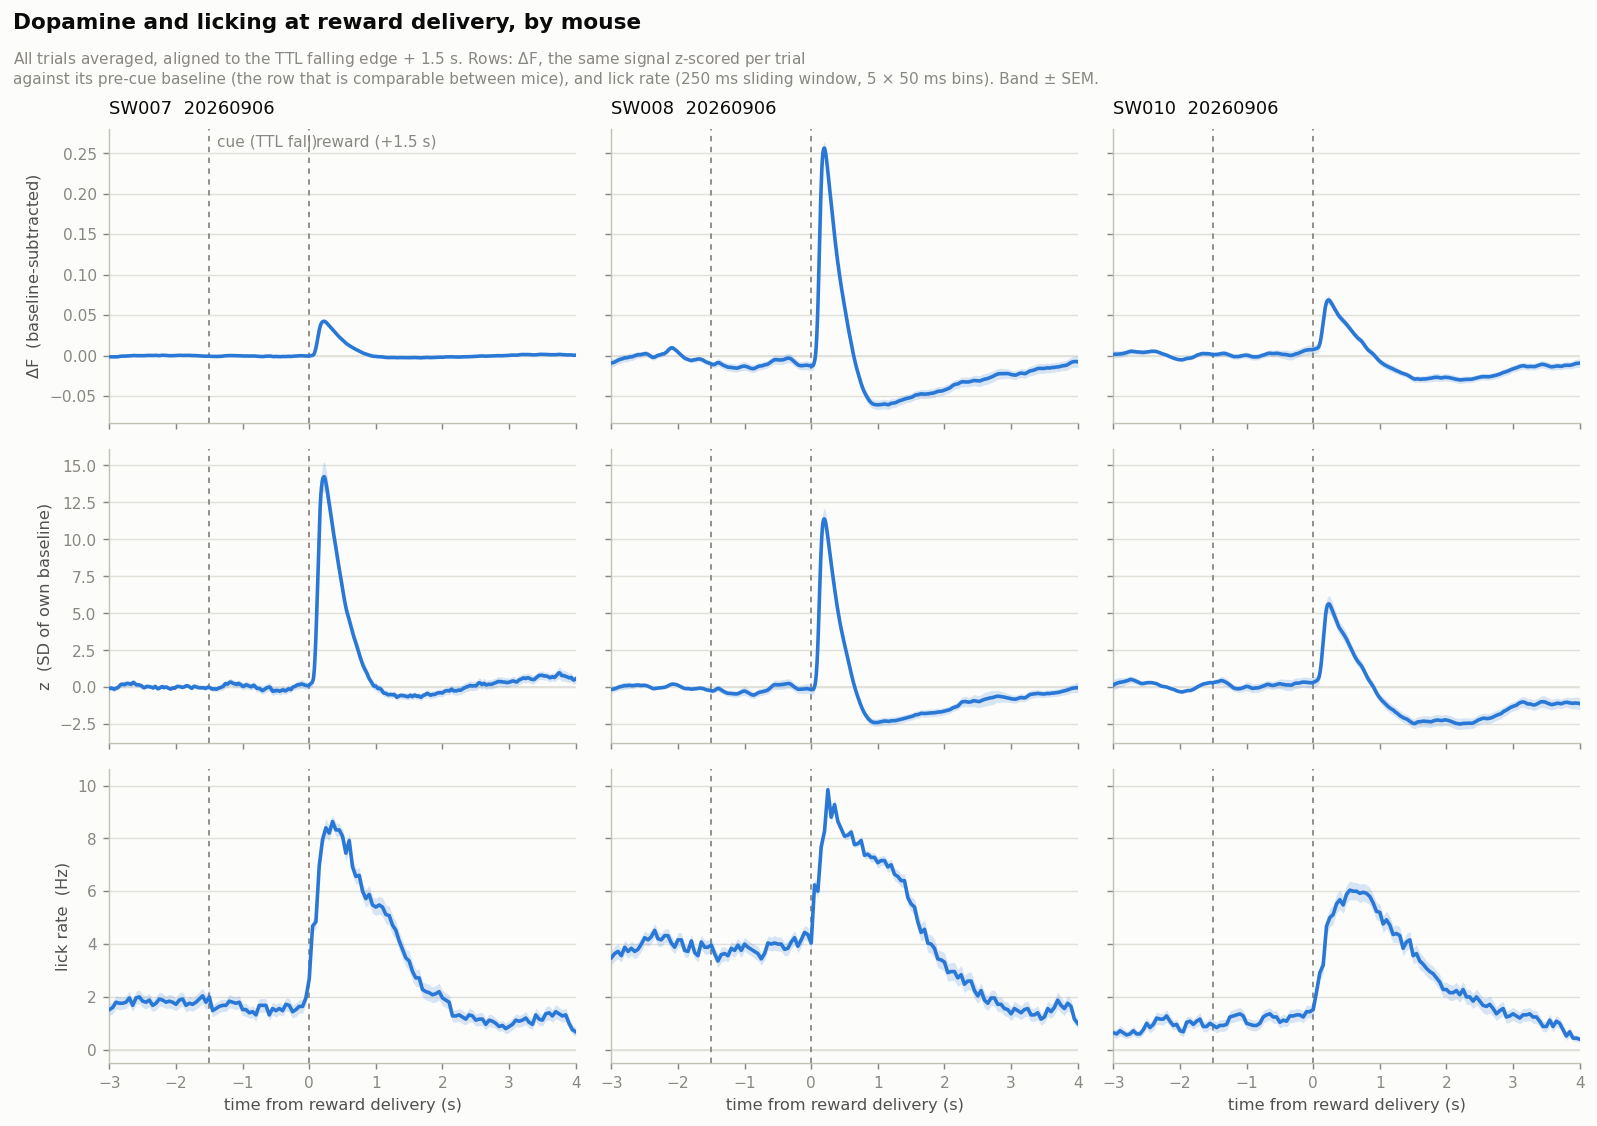

,recording,behavior,trials,peak dF,sem,peak latency (s),dip dF,peak z,lick pre (Hz),lick peak (Hz),lick peak (s)
0,SW007_20260906,True,100,0.0424,0.0016,0.225,-0.0029,14.2,1.82,8.64,0.35
1,SW008_20260906,True,100,0.2566,0.0075,0.196,-0.0611,11.4,3.95,9.84,0.25
2,SW010_20260906,True,100,0.0687,0.0052,0.230,-0.0294,5.6,0.88,6.04,0.55


In [25]:
# Reward time is the TTL falling edge (cue) + TTL_TRACE, on every recording --
# no behavior file required, and on the paired ones it matches Bpod's Reward_on
# to about a millisecond. Licking is the only row that needs Bpod.
REWARD_BASELINE = (-2.5, -1.6)   # the 0.9 s ending just before cue onset
REWARD_COLOR = "#2a78d6"

# Finer than the stim figure's 1 s window: every trial is rewarded, so all of
# them count toward one curve, and consummatory licking rises within ~200 ms of
# reward. A 1 s window would smear that onset away.
REWARD_LICK_BIN, REWARD_LICK_WIN = 0.05, 5   # 250 ms window every 50 ms
REWARD_XLABEL = "time from reward delivery (s)"

ROW_LABELS = ("$\\Delta$F  (baseline-subtracted)",
              "z  (SD of own baseline)",
              "lick rate  (Hz)")


def reward_tail(photo, trace=TTL_TRACE):
    """Seconds from reward to the earliest next trial start in this recording.

    The widest tail still free of the next trial -- and so of the next stim,
    on a day that stimulated. It is 4.13 s on 20260905 but only 2.58 s on
    20260904, which is why this is measured per recording rather than fixed.
    """
    rises, falls = photo.sync_rises, photo.sync_falls
    n = min(falls.size, rises.size - 1)
    return float((rises[1:n + 1] - falls[:n]).min() - trace)


# One window for the whole figure, so the panels stay comparable: the shortest
# safe tail across the recordings shown, rounded down to 0.1 s.
REWARD_WINDOW = (-3.0, min(4.0, float(np.floor(
    min(reward_tail(photo) for photo, _ in recs.values()) * 10) / 10)))

fig, axes = session_grid(len(ROW_LABELS), names)

rows = []
for j, name in enumerate(names):
    photo, sess = recs[name]
    rew = event_times_of(photo, sess, "reward")
    t, M = pdm.epoch_signal(photo, rew, REWARD_WINDOW, which="F")
    # (time base, mean, sem) per row -- dopamine twice in different units, then
    # behaviour. Never a twin y-axis: dF, z and Hz share no meaningful scale.
    series = [(t,) + pdm.mean_sem(pdm.baseline_subtract(M, t, REWARD_BASELINE)),
              (t,) + pdm.mean_sem(pdm.zscore_baseline(M, t, REWARD_BASELINE))]
    if sess is not None:
        tl, R = lick_rate(sess, rew, REWARD_WINDOW, REWARD_LICK_BIN, REWARD_LICK_WIN)
        series.append((tl,) + pdm.mean_sem(R))

    for r in range(len(ROW_LABELS)):
        ax = axes[r, j]
        ax.set_facecolor(SURFACE)
        if r >= len(series):
            no_licks_panel(ax, REWARD_XLABEL)
            continue
        tt, mu, sem = series[r]
        ax.fill_between(tt, mu - sem, mu + sem, color=REWARD_COLOR, alpha=0.18,
                        linewidth=0, zorder=2)
        # One series per panel, so the panel title carries identity -- no legend
        # needed, and colour is not being asked to tell the mice apart.
        ax.plot(tt, mu, color=REWARD_COLOR, linewidth=2.0, zorder=4)

        style_panel(ax, marks=(-TTL_TRACE, 0),
                    title=(name.replace("_", "  ")
                           + ("   (TTL only)" if sess is None else "") if r == 0 else ""),
                    xlabel=(REWARD_XLABEL if r == len(ROW_LABELS) - 1 else ""))
        ax.set_xlim(*REWARD_WINDOW)

    (t_df, df, sem_df), (_, z, _) = series[0], series[1]
    w = (t_df >= 0) & (t_df <= 2)
    i = int(np.nanargmax(df[w]))
    # "peak latency" doubles as the check on TTL_TRACE: the transient sits
    # ~0.2 s after reward on the paired sessions, so a latency far from that
    # would mean this recording did not run a 1.5 s trace period.
    row = {"recording": name, "behavior": sess is not None,
           "trials": int(np.isfinite(M[:, 0]).sum()),
           "peak dF": round(float(df[w][i]), 4),
           "sem": round(float(sem_df[w][i]), 4),
           "peak latency (s)": round(float(t_df[w][i]), 3),
           "dip dF": round(float(np.nanmin(df[w])), 4),
           "peak z": round(float(np.nanmax(z[w])), 1)}
    if sess is not None:
        t_lk, lk = series[2][0], series[2][1]
        wl = (t_lk >= 0) & (t_lk <= 2)
        row |= {"lick pre (Hz)": round(float(lk[t_lk < -TTL_TRACE].mean()), 2),
                "lick peak (Hz)": round(float(np.nanmax(lk[wl])), 2),
                "lick peak (s)": round(float(t_lk[wl][np.nanargmax(lk[wl])]), 2)}
    rows.append(row)

# Event labels once, in the first panel only -- repeating them in every panel
# would be nine times the ink for the same information. They go at the top of
# the dF row, the one corner no curve reaches.
hi = axes[0, 0].get_ylim()[1]
for x, lab in ((-TTL_TRACE, "cue (TTL fall)"), (0, f"reward (+{TTL_TRACE:g} s)")):
    axes[0, 0].annotate(lab, (x, hi), xytext=(4, -3), textcoords="offset points",
                        ha="left", va="top", color=MUTED, fontsize=8.5)

for r, ylabel in enumerate(ROW_LABELS):
    axes[r, 0].set_ylabel(ylabel, color=INK_2, fontsize=9)

fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.text(0.005, 0.99, "Dopamine and licking at reward delivery, by mouse",
         ha="left", va="top", color=INK, fontsize=12, fontweight="bold")
fig.text(0.005, 0.957, "All trials averaged, aligned to the TTL falling edge + "
         f"{TTL_TRACE:g} s. Rows: $\\Delta$F, the same signal z-scored per trial\n"
         "against its pre-cue baseline (the row that is comparable between mice), and "
         "lick rate (250 ms sliding window, 5 × 50 ms bins). Band ± SEM.",
         ha="left", va="top", color=MUTED, fontsize=8.5)
plt.show()

reward_peaks = pd.DataFrame(rows)
reward_peaks


## Stim vs reward, side by side

Sections 3 and 5 each share y *across* mice, which answers "who responds more?".
This one shares y **within** a mouse, across the two events — the question that
setup cannot answer: for this animal, how big is the stim transient next to the
one reward already produces?

$\Delta$F only, and dopamine only. Putting z or a lick rate in the same row
would hand the two panels different scales again, which is exactly what the
shared axis is here to avoid.


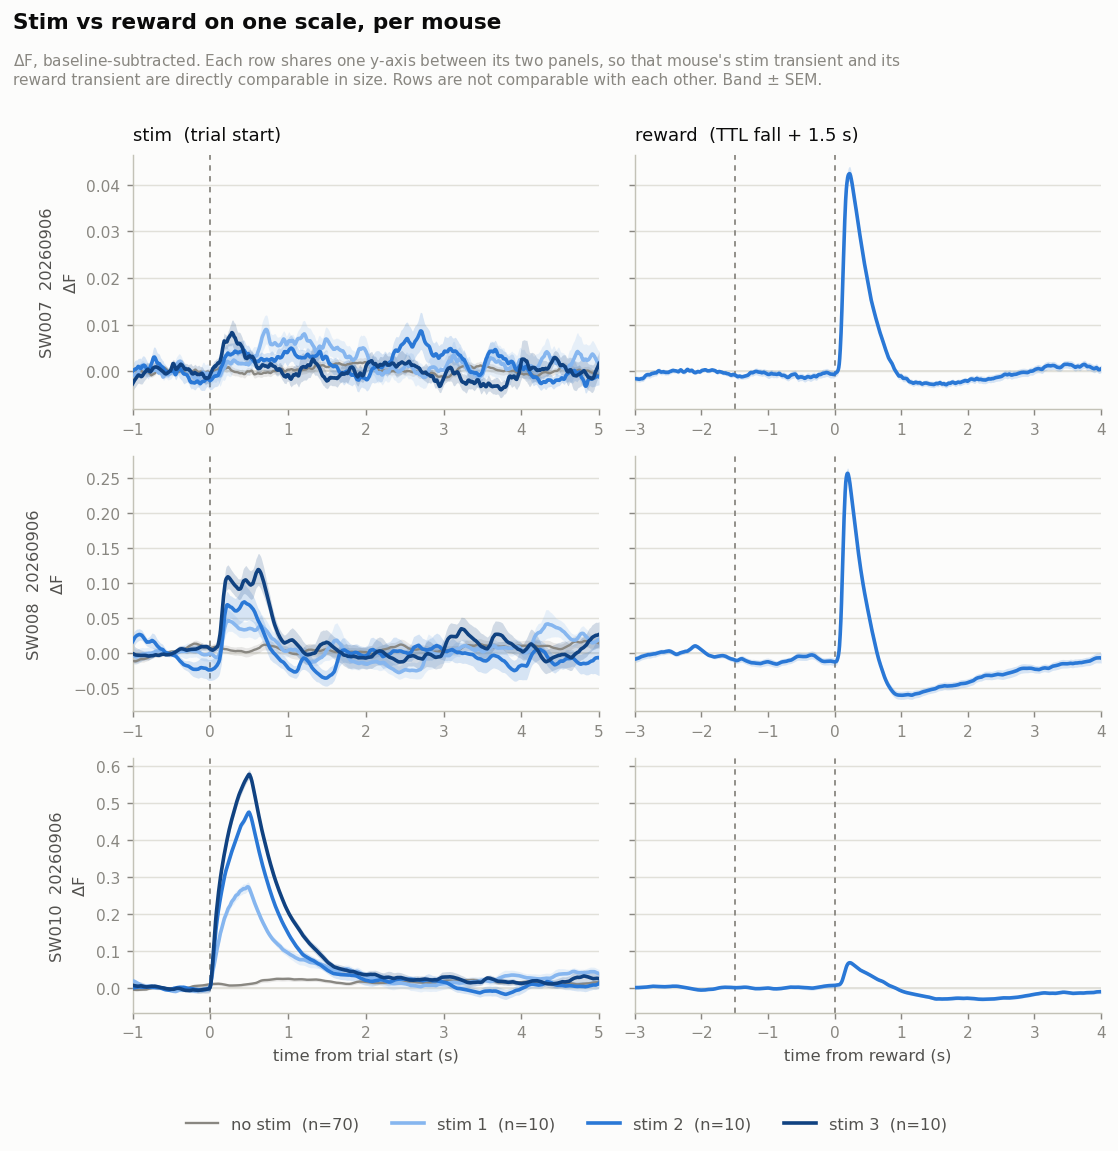

In [26]:
# Stim and reward side by side, one row per recording, **y shared across the
# pair**. That shared axis is the point: everywhere else in this notebook y is
# shared within a row *across* mice, which answers "who responds more?". Here it
# is shared within a mouse *across* events, which answers the other question --
# for this animal, how does the stim transient compare with the one reward
# already produces? $\Delta$F only, and dopamine only: two normalisations, or a
# lick row, would put the two panels back on two different scales.
#
# x is deliberately *not* shared -- the columns are different events with
# different windows.
require_names(names)

PAIR_H, PAIR_HEADER, PAIR_FOOT = 2.5, 0.85, 0.45   # inches: row, title strip, legend

fig, axes = plt.subplots(len(names), 2, squeeze=False, sharey="row",
                         figsize=(8.6, PAIR_H * len(names) + PAIR_HEADER + PAIR_FOOT),
                         dpi=130)
fig.patch.set_facecolor(SURFACE)

for r, name in enumerate(names):
    photo, sess = recs[name]

    # Left: aligned to the TTL rising edge, split by stim level where Bpod says.
    draw_psth(axes[r, 0], psth(photo, "trial_start", sess),
              title="stim  (trial start)" if r == 0 else "",
              xlabel="time from trial start (s)" if r == len(names) - 1 else "",
              stim_known=sess is not None)
    axes[r, 0].set_xlim(*WINDOW)

    # Right: every trial is rewarded, so there is nothing to split by -- one
    # curve, in the reward figure's blue rather than a stim-ramp colour, so it
    # never reads as a fourth condition.
    t, M = pdm.epoch_signal(photo, event_times_of(photo, sess, "reward"),
                            REWARD_WINDOW, which="F")
    mu, sem = pdm.mean_sem(pdm.baseline_subtract(M, t, REWARD_BASELINE))
    ax = axes[r, 1]
    ax.fill_between(t, mu - sem, mu + sem, color=REWARD_COLOR, alpha=0.18,
                    linewidth=0, zorder=2)
    ax.plot(t, mu, color=REWARD_COLOR, linewidth=2.0, zorder=4)
    style_panel(ax, marks=(-TTL_TRACE, 0),
                title=f"reward  (TTL fall + {TTL_TRACE:g} s)" if r == 0 else "",
                xlabel="time from reward (s)" if r == len(names) - 1 else "")
    ax.set_xlim(*REWARD_WINDOW)

    axes[r, 0].set_ylabel(name.replace("_", "  ")
                          + ("\n(TTL only)" if sess is None else "")
                          + "\n$\\Delta$F", color=INK_2, fontsize=9, linespacing=1.6)

figure_legend(fig, axes[:, 0])   # stim levels; the reward panel has one series

# Strips reserved in inches, so the header keeps its size whatever the row count.
h = fig.get_figheight()
fig.tight_layout(rect=(0, PAIR_FOOT / h, 1, 1 - PAIR_HEADER / h))
fig.text(0.005, 1 - 0.12 / h, "Stim vs reward on one scale, per mouse",
         ha="left", va="top", color=INK, fontsize=12, fontweight="bold")
fig.text(0.005, 1 - 0.42 / h, "$\\Delta$F, baseline-subtracted. Each row shares one "
         "y-axis between its two panels, so that mouse's stim transient and its\nreward "
         "transient are directly comparable in size. Rows are not comparable with each "
         "other. Band ± SEM.",
         ha="left", va="top", color=MUTED, fontsize=8.5)
plt.show()



| | SW007 | SW008 | SW010 |
|---|---|---|---|
| whole-trace SD | 0.0066 | 0.0511 | 0.0497 |
| peak $\Delta$F | 0.034 | 0.183 | 0.046 |
| **peak in own SD** | **11.3** | 8.5 | **3.9** |
| single trials clearing 2 SD | 99% | 97% | 73% |
| latency SD | 30 ms | 59 ms | 187 ms |
| avg / mean single-trial peak | 0.97 | 0.94 | 0.78 |